# Observations & power-plant NOx distribution — US + World

Two-row map (US, World) over a row of histograms (US, World) of annual NOx emissions.
Updated for paper revision:
- US data switched to the 100 m localized pipeline (`pipeline_100m_run/Run_100m_20260414/...`).
- World data switched to the 100 m re-labelling output (`pipeline_test_labelling_100m/Run_100m_20260428/`).
- Colorbar / printout label changed from "Snapshot" to "Observation".


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd

plt.rcdefaults()
plt.rcParams.update({
    'font.family': 'Nimbus Roman',
    'font.size': 16,
    'axes.labelsize': 20,
    'axes.titlesize': 26,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 18,
    'figure.titlesize': 32,
})

# ---- Paths (paper revision, 100 m wind everywhere) ----
# US_HOURLY_CSV: 2026-04-28 LST-fixed augment_final_table.py output (fixed
# winter-offset Local Standard Time conversion, matching EPA CAMPD's
# reporting convention; previously the DST-aware IANA conversion shifted
# ~67% of summer rows by +1 hour).
US_HOURLY_CSV     = '/net/fs06/d3/rzhuang/TROPOMI/pipeline_100m_run/Run_100m_20260414/updated_tropomi_hourly_emissions_full_variables_augmented_localtz.csv'
US_FACILITY_CSV   = '/net/fs06/d3/rzhuang/TROPOMI/data/us/facility_emissions_by_plant_comprehensive.csv'
# WORLD_EMIT_CSV: 2026-04-28 100 m re-labelling stage-2 output (uses ERA5
# 100 m wind for plume direction, replacing the TROPOMI 10 m embedded wind
# used by Run_3). Stage-2 only — full-variable stages have not been re-run
# for the 100 m world pipeline yet, so only `location` is used here for
# counting observations per plant.
WORLD_EMIT_CSV    = '/net/fs06/d3/rzhuang/TROPOMI/data/world/pipeline_test_labelling_100m/Run_100m_20260428/valid_tropomi_emissions_with_qa.csv'
WORLD_LOCATIONS_CSV = '/net/fs06/d3/rzhuang/TROPOMI/data/world/power_plant_location/power_plants_with_combined_nearby_stats.csv'
OUTPUT_DIR        = '/net/fs06/d3/rzhuang/TROPOMI/results/paper_figures'
os.makedirs(OUTPUT_DIR, exist_ok=True)


In [2]:
def load_us_data():
    """Top-500 US plants with per-plant observation counts and metric-ton emissions."""
    filtered_df  = pd.read_csv(US_HOURLY_CSV, low_memory=False)
    locations_df = pd.read_csv(US_FACILITY_CSV)
    locations_df = locations_df[:500].copy()

    counts = filtered_df.groupby('location').size().rename('count_obs').reset_index()
    counts_dict = counts.set_index('location')['count_obs'].to_dict()
    locations_df['counts'] = locations_df['Facility_ID'].map(counts_dict)

    us = locations_df.rename(columns={
        'Longitude': 'longitude',
        'Latitude':  'latitude',
        'Total_NOx_Mass': 'nox_emissions',
    }).copy()
    # short tons -> metric tons, divide by 6 years to get per-year
    us['nox_emissions'] = us['nox_emissions'] * 0.907185 / 6
    us['source'] = 'US'
    return us

def load_world_data():
    """Top-6000 world plants with per-plant observation counts (already metric tons/year)."""
    filtered_df  = pd.read_csv(WORLD_EMIT_CSV, low_memory=False)
    locations_df = pd.read_csv(WORLD_LOCATIONS_CSV)
    locations_df = locations_df[:6000].copy()

    counts = filtered_df.groupby('location').size().rename('count_obs').reset_index()
    counts_dict = counts.set_index('location')['count_obs'].to_dict()
    locations_df['counts'] = locations_df['ID'].map(counts_dict)

    world = locations_df.rename(columns={'nox_emis_ty': 'nox_emissions'}).copy()
    world['source'] = 'World'
    return world

def aesthetic_cmap():
    return mcolors.LinearSegmentedColormap.from_list(
        'custom_viridis', ['#440154', '#31688e', '#35b779', '#fde725'], N=256)

def plot_map(ax, gdf, title, extent, norm):
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND,      facecolor='#f8f8f8', edgecolor='none')
    ax.add_feature(cfeature.OCEAN,     facecolor='#e6f3ff', alpha=0.8)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, color='#404040')
    ax.add_feature(cfeature.BORDERS,   linewidth=0.5, color='#666666', alpha=0.7)

    valid = gdf.dropna(subset=['counts', 'nox_emissions_scaled'])
    if len(valid) == 0:
        ax.set_title(title, fontsize=18, pad=20, weight='bold')
        return None

    sc = ax.scatter(valid['longitude'], valid['latitude'],
                    s=valid['nox_emissions_scaled'], c=valid['counts'],
                    cmap=aesthetic_cmap(), norm=norm,
                    edgecolors='none', linewidth=0, alpha=0.85, marker='o',
                    transform=ccrs.PlateCarree())

    gl = ax.gridlines(draw_labels=True, linestyle=':', alpha=0.4,
                      linewidth=0.5, color='#666666')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 18, 'color': '#000000'}
    gl.ylabel_style = {'size': 18, 'color': '#000000'}
    ax.set_title(title, fontsize=28, pad=20, weight='bold', color='#000000')
    return sc

In [3]:
print('Loading US data...')
us_data    = load_us_data()
print('Loading World data...')
world_data = load_world_data()

# Histogram source data (annual emissions in metric tons)
us_df    = pd.read_csv(US_FACILITY_CSV)
world_df = pd.read_csv(WORLD_LOCATIONS_CSV)
us_df['annual_nox_emission']    = (us_df['Total_NOx_Mass'] / 6) * 0.907185
world_df.rename(columns={'nox_emis_ty': 'annual_nox_emission'}, inplace=True)

us_clean    = us_df.dropna(subset=['annual_nox_emission'])
us_clean    = us_clean[us_clean['annual_nox_emission'] > 0]
world_clean = world_df.dropna(subset=['annual_nox_emission'])
world_clean = world_clean[world_clean['annual_nox_emission'] > 0]
us_top    = us_clean.nlargest(500,  'annual_nox_emission')
world_top = world_clean.nlargest(6000, 'annual_nox_emission')

us_counts    = us_data[['counts']].dropna()
world_counts = world_data[['counts']].dropna()
norm_us    = mcolors.Normalize(vmin=us_counts['counts'].min(),    vmax=us_counts['counts'].max())
norm_world = mcolors.Normalize(vmin=world_counts['counts'].min(), vmax=world_counts['counts'].max())

nox_scaling_factor = 0.01
us_data['nox_emissions_scaled']    = us_data['nox_emissions']    * nox_scaling_factor
world_data['nox_emissions_scaled'] = world_data['nox_emissions'] * nox_scaling_factor

gdf_us = gpd.GeoDataFrame(us_data,
    geometry=gpd.points_from_xy(us_data['longitude'], us_data['latitude']),
    crs='EPSG:4326')
gdf_world = gpd.GeoDataFrame(world_data,
    geometry=gpd.points_from_xy(world_data['longitude'], world_data['latitude']),
    crs='EPSG:4326')

print(f'US plants={len(gdf_us)}, World plants={len(gdf_world)}')
print(f'US obs/plant range = {us_counts["counts"].min():.0f} - {us_counts["counts"].max():.0f}')
print(f'World obs/plant range = {world_counts["counts"].min():.0f} - {world_counts["counts"].max():.0f}')

Loading US data...
Loading World data...
US plants=500, World plants=6000
US obs/plant range = 701 - 2263
World obs/plant range = 2 - 350


/home/rzhuang/.conda/envs/rzhuang-env/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/rzhuang/.conda/envs/rzhuang-env/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/tmp/ipykernel_1481525/3152089883.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1481525/3152089883.py:68: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1481525/3152089883.py:68: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1481525/3152089883.py:70: UserWarning: Glyph 8321 (\N{S

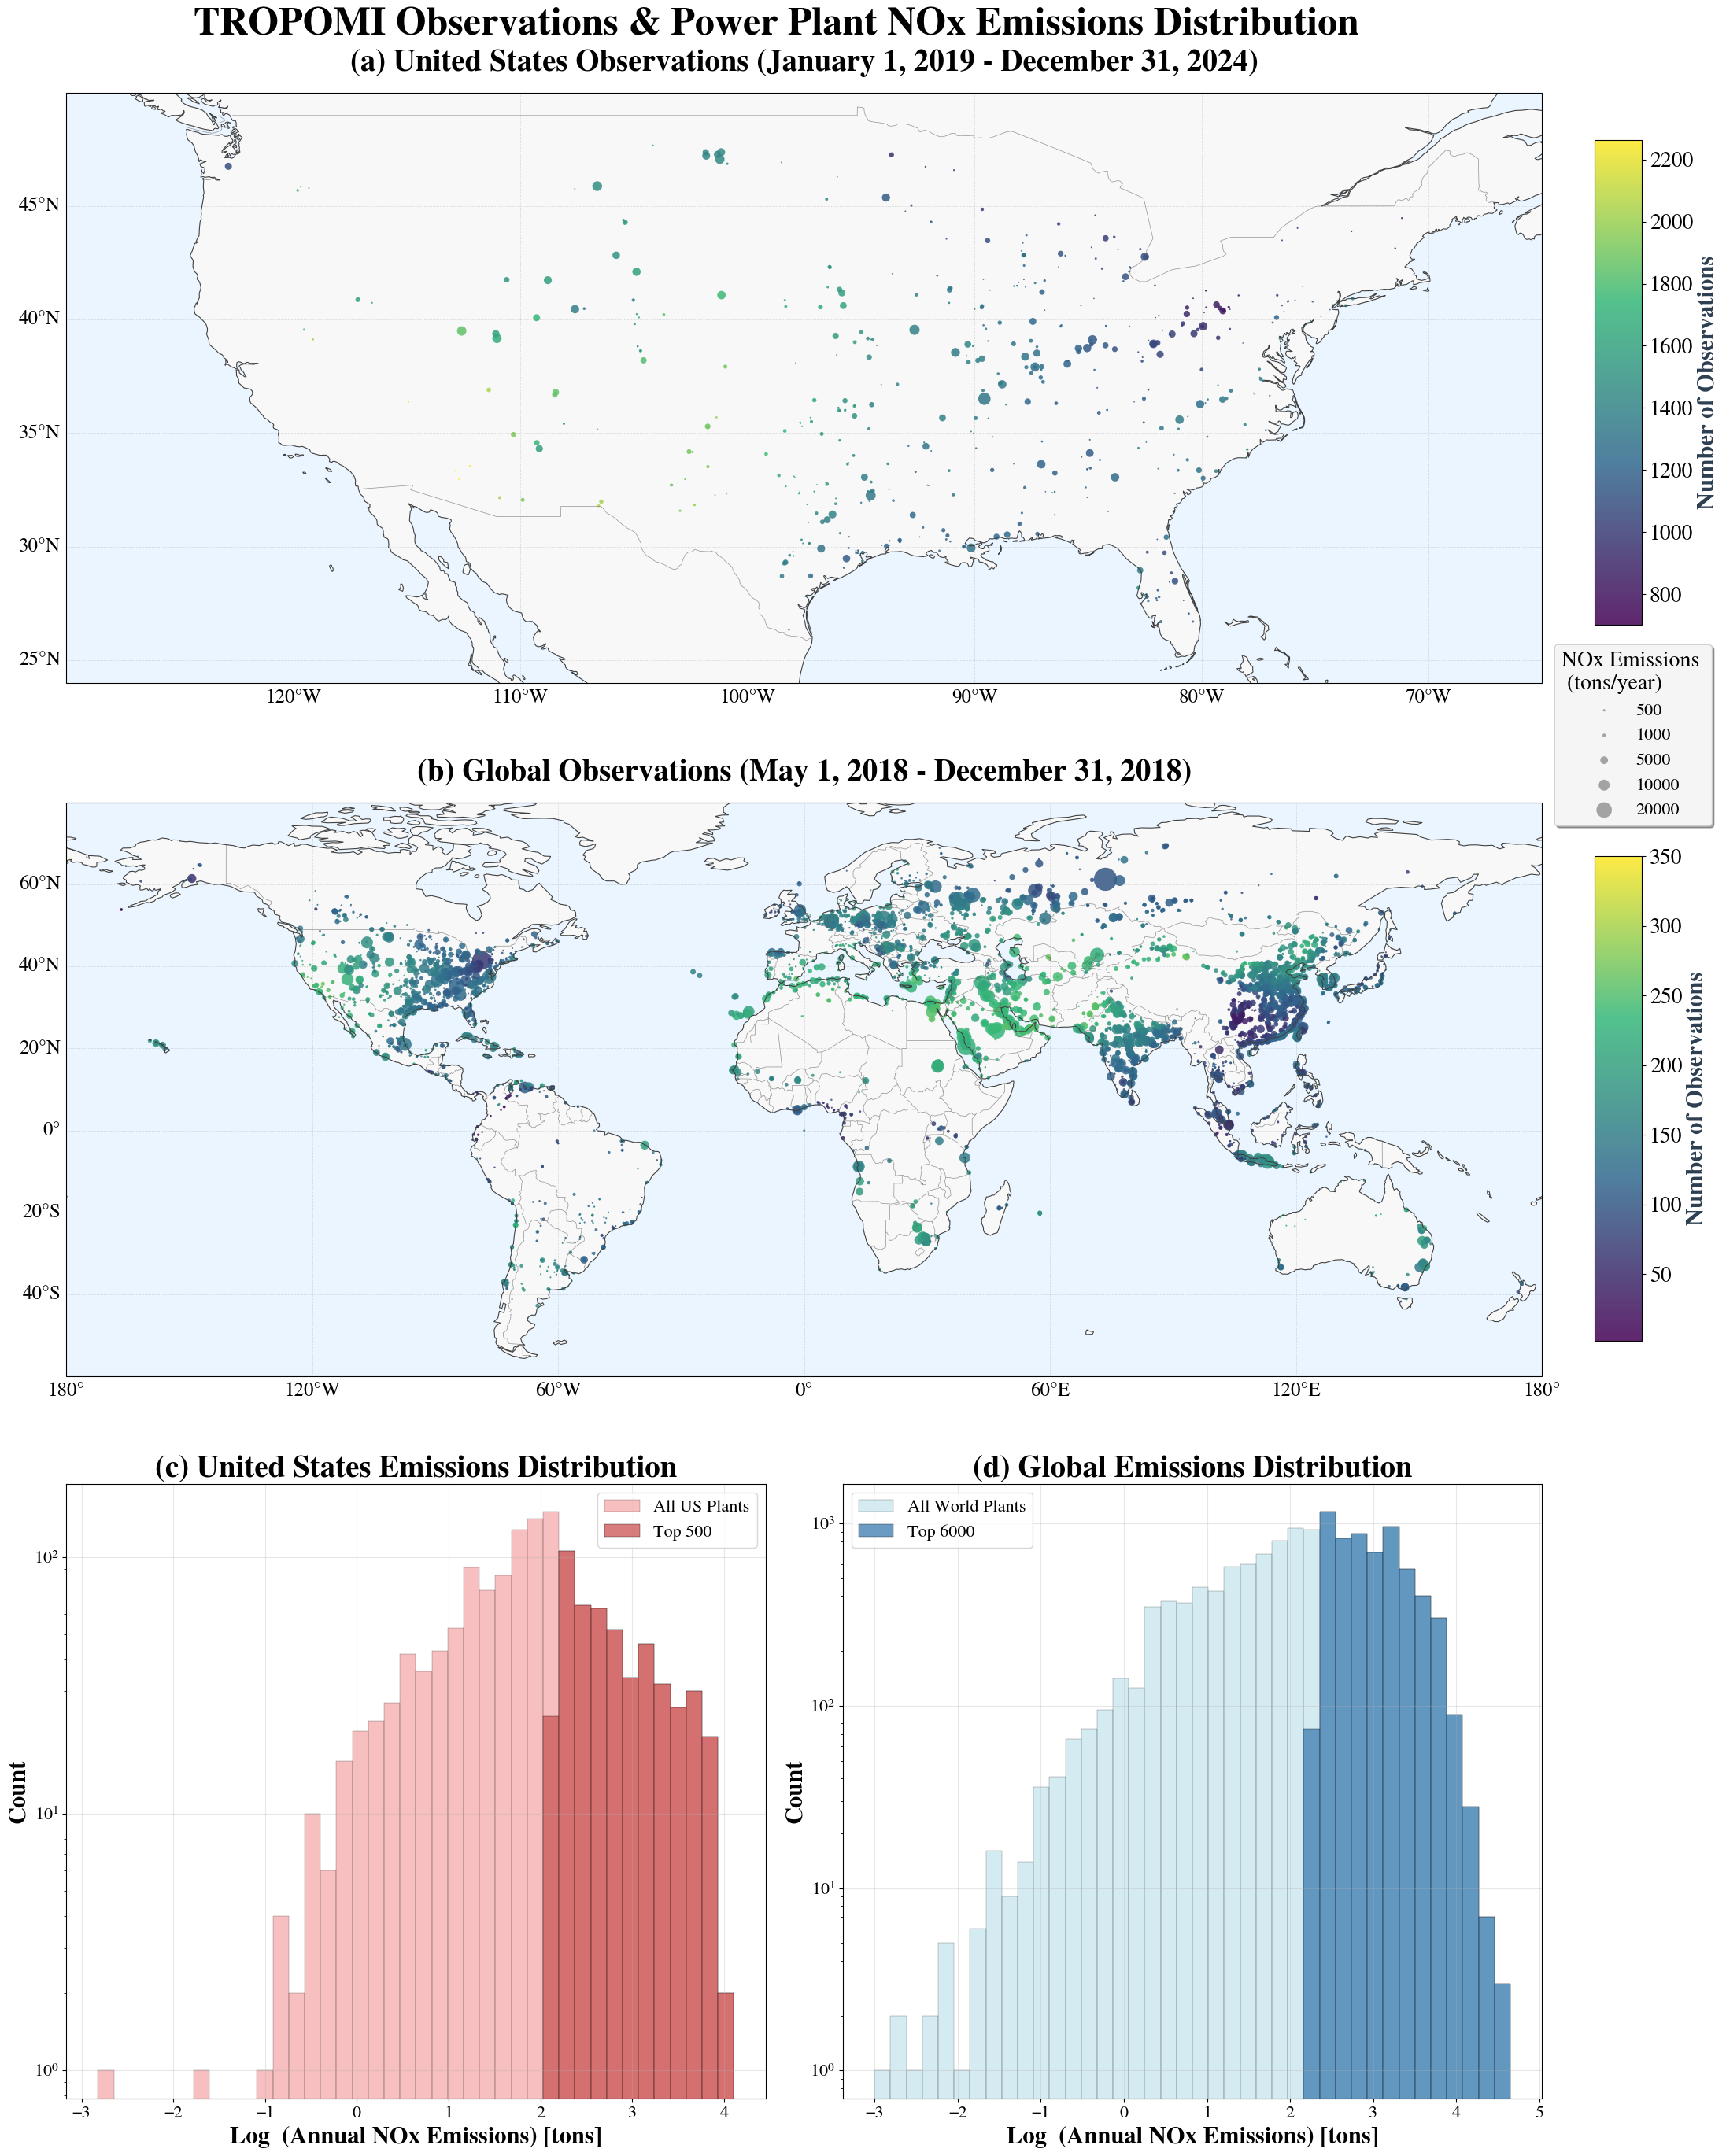


SUMMARY
US Power Plants:    500
World Power Plants: 6,000
US Observation Range:    701 - 2263
World Observation Range: 2 - 350
Saved: /net/fs06/d3/rzhuang/TROPOMI/results/paper_figures/combined_analysis_3row.pdf


In [4]:
fig = plt.figure(figsize=(20, 28))
fig.suptitle('TROPOMI Observations & Power Plant NOx Emissions Distribution',
             fontsize=36, y=0.98, weight='bold', color='#000000')

ax1 = plt.subplot(3, 2, (1, 2), projection=ccrs.PlateCarree())
sc1 = plot_map(ax1, gdf_us,
               '(a) United States Observations (January 1, 2019 - December 31, 2024)',
               [-130, -65, 24, 50], norm_us)

ax2 = plt.subplot(3, 2, (3, 4), projection=ccrs.PlateCarree())
sc2 = plot_map(ax2, gdf_world,
               '(b) Global Observations (May 1, 2018 - December 31, 2018)',
               [-180, 180, -60, 80], norm_world)

# (c) US histogram
ax3 = plt.subplot(3, 2, 5)
us_log     = np.log10(us_clean['annual_nox_emission'])
us_top_log = np.log10(us_top['annual_nox_emission'])
us_bins    = np.linspace(us_log.min(), us_log.max(), 41)
ax3.hist(us_log,     bins=us_bins, alpha=0.5, color='lightcoral', label='All US Plants', edgecolor='black', linewidth=0.3)
ax3.hist(us_top_log, bins=us_bins, alpha=0.8, color='indianred',  label='Top 500',       edgecolor='black', linewidth=0.3)
ax3.set_xlabel('Log\u2081\u2080(Annual NOx Emissions) [tons]', fontweight='bold', fontsize=22)
ax3.set_ylabel('Count', fontweight='bold', fontsize=22)
ax3.set_yscale('log')
ax3.set_title('(c) United States Emissions Distribution', fontweight='bold', fontsize=28)
ax3.legend(fontsize=16); ax3.grid(alpha=0.3)

# (d) World histogram
ax4 = plt.subplot(3, 2, 6)
world_log     = np.log10(world_clean['annual_nox_emission'])
world_top_log = np.log10(world_top['annual_nox_emission'])
world_bins    = np.linspace(world_log.min(), world_log.max(), 41)
ax4.hist(world_log,     bins=world_bins, alpha=0.5, color='lightblue', label='All World Plants', edgecolor='black', linewidth=0.3)
ax4.hist(world_top_log, bins=world_bins, alpha=0.8, color='steelblue', label='Top 6000',         edgecolor='black', linewidth=0.3)
ax4.set_xlabel('Log\u2081\u2080(Annual NOx Emissions) [tons]', fontweight='bold', fontsize=22)
ax4.set_ylabel('Count', fontweight='bold', fontsize=22)
ax4.set_yscale('log')
ax4.set_title('(d) Global Emissions Distribution', fontweight='bold', fontsize=28)
ax4.legend(fontsize=16); ax4.grid(alpha=0.3)

fig.subplots_adjust(bottom=0.1, top=0.94, left=0.05, right=0.95, hspace=0.35, wspace=0.3)

# Colorbars
cbar_ax1 = fig.add_axes([1.02, 0.7, 0.03, 0.22])
if sc1 is not None:
    cbar1 = fig.colorbar(sc1, cax=cbar_ax1, orientation='vertical')
    cbar1.set_label('Number of Observations', fontsize=22, weight='bold', color='#2c3e50')
    cbar1.ax.tick_params(labelsize=20, colors='#000000')

cbar_ax2 = fig.add_axes([1.02, 0.375, 0.03, 0.22])
if sc2 is not None:
    cbar2 = fig.colorbar(sc2, cax=cbar_ax2, orientation='vertical')
    cbar2.set_label('Number of Observations', fontsize=22, weight='bold', color='#2c3e50')
    cbar2.ax.tick_params(labelsize=20, colors='#000000')

# Marker-size legend
legend_sizes  = [5, 10, 50, 100, 200]
legend_labels = ['500', '1000', '5000', '10000', '20000']
legend_elems  = [plt.scatter([], [], s=s, c='gray', alpha=0.7, edgecolors='none', linewidth=0)
                 for s in legend_sizes]
leg = fig.legend(legend_elems, legend_labels,
                 title='NOx Emissions \n (tons/year)',
                 loc='center right', bbox_to_anchor=(1.1, 0.65),
                 ncol=1, fontsize=16, title_fontsize=20,
                 frameon=True, fancybox=True, shadow=True)
leg.get_frame().set_facecolor('white'); leg.get_frame().set_alpha(0.9)

plt.tight_layout()
out_pdf = os.path.join(OUTPUT_DIR, 'combined_analysis_3row.pdf')
plt.savefig(out_pdf, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()

print('\n' + '=' * 60)
print('SUMMARY')
print('=' * 60)
print(f'US Power Plants:    {len(gdf_us):,}')
print(f'World Power Plants: {len(gdf_world):,}')
print(f'US Observation Range:    {us_counts["counts"].min():.0f} - {us_counts["counts"].max():.0f}')
print(f'World Observation Range: {world_counts["counts"].min():.0f} - {world_counts["counts"].max():.0f}')
print('=' * 60)
print(f'Saved: {out_pdf}')